# 射频指纹识别 (RF Fingerprint Identification) 深度学习实战

## 什么是射频指纹识别?

每个无线设备(手机、路由器、IoT设备)的硬件都有微小的制造差异(振荡器偏差、
功率放大器非线性、混频器不平衡等), 这些差异会体现在发射信号中, 形成独特的
"射频指纹"。RFFI 通过深度学习提取这些指纹来识别/认证设备。

```
发射设备 → 无线信道 → 接收机 → IQ采样 → 深度学习 → 设备身份
  (指纹)    (干扰)    (采集)   (数据)   (分类器)   (结果)
```

## 本课内容
1. IQ信号基础与处理
2. 1D CNN 射频指纹分类器
3. RF数据增强技术
4. 迁移学习与域适应
5. 分类评估与Open-set识别
6. 模型轻量化
7. 完整RFFI实验流程

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

## 1. IQ信号基础与处理

### 什么是IQ信号?

接收机将射频信号下变频后得到两路信号:
- **I (In-phase)**: 同相分量
- **Q (Quadrature)**: 正交分量

```
s(t) = I(t) * cos(2πf_c*t) - Q(t) * sin(2πf_c*t)
```

IQ信号是RFFI最常用的输入格式, 形状通常为 (2, N) 或 (N, 2):
- 2 = I和Q两个通道 (类似图像的RGB通道)
- N = 采样点数

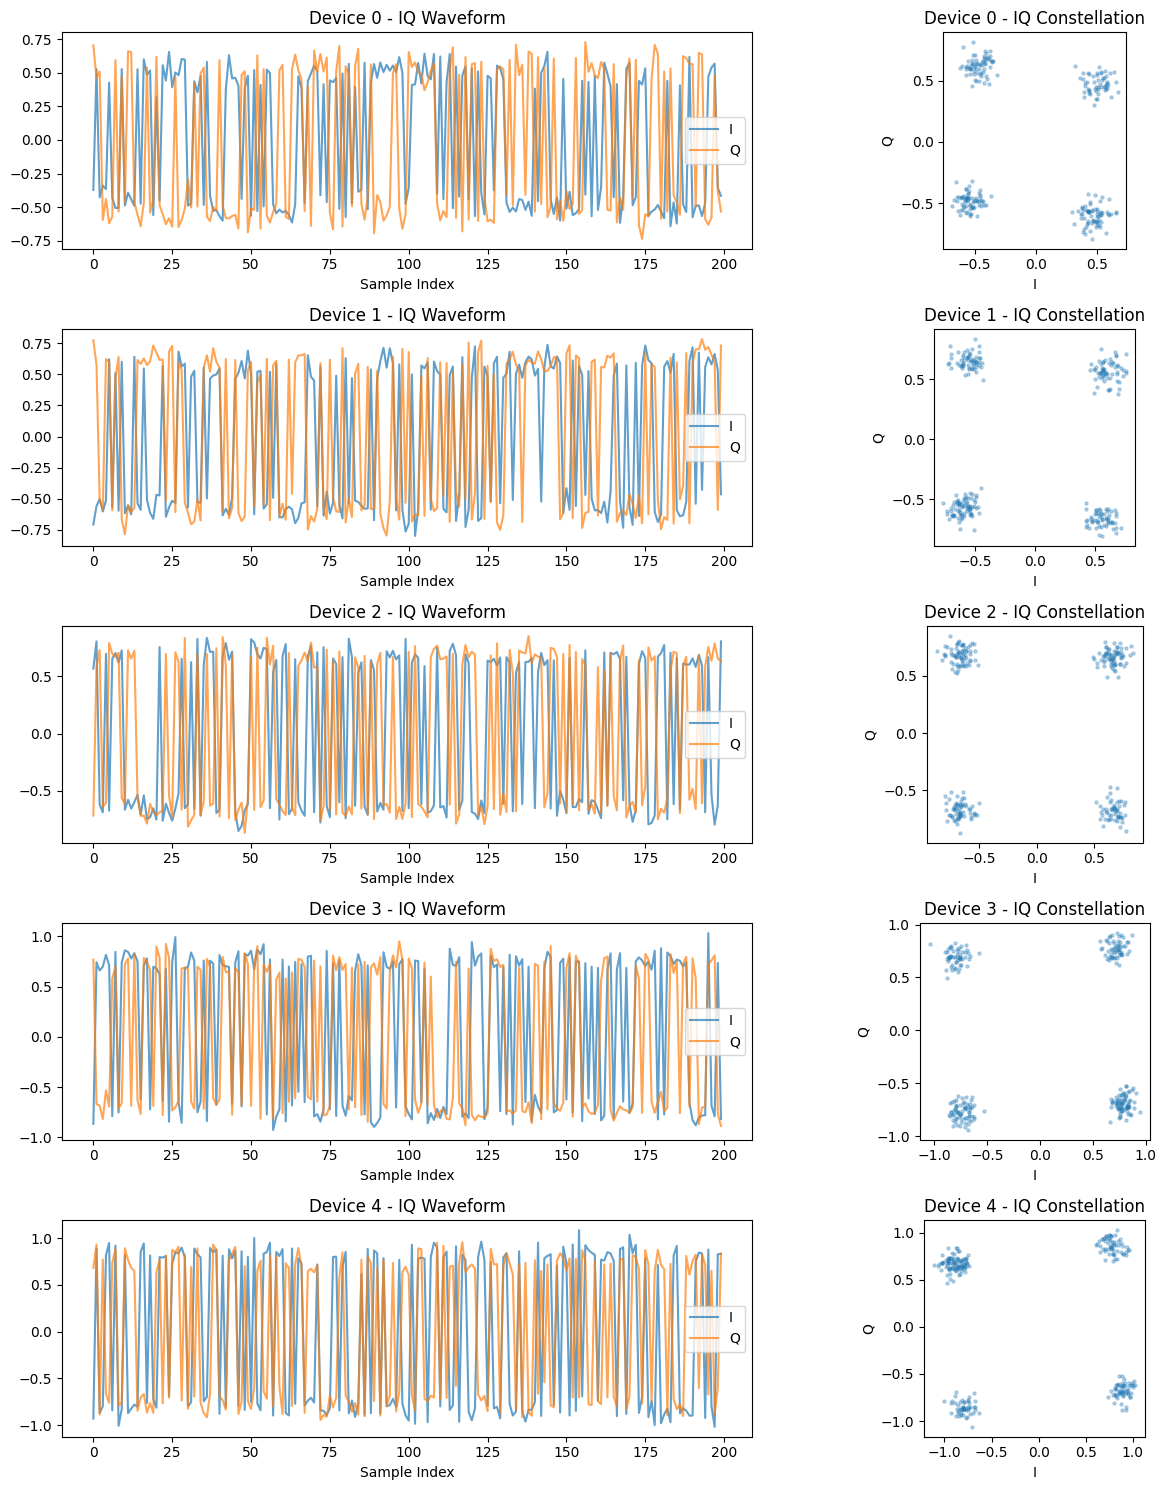

不同设备的IQ波形和星座图有细微差异, 这就是射频指纹


In [3]:
# 模拟不同设备的IQ信号
np.random.seed(42)
n_samples = 1024  # 采样点数
n_devices = 5     # 设备数量

def generate_device_iq(device_id, n_points=1024, snr=20):
    """模拟某设备的IQ信号, 包含设备特有的硬件指纹"""
    t = np.linspace(0, 1, n_points)
    
    # 基带信号 (QPSK调制)
    symbols = np.random.choice([-1, 1], size=n_points) + 1j * np.random.choice([-1, 1], size=n_points)
    signal = symbols / np.sqrt(2)
    
    # 设备指纹: 每个设备有不同的硬件缺陷
    np.random.seed(device_id * 100)
    
    # 1. 载波频偏 (CFO) - 振荡器偏差
    cfo = (device_id - 2) * 0.01  # 每个设备不同的频偏
    signal = signal * np.exp(1j * 2 * np.pi * cfo * t)
    
    # 2. IQ不平衡 - 混频器缺陷
    amplitude_imbalance = 1.0 + (device_id - 2) * 0.05
    phase_imbalance = (device_id - 2) * 0.03
    I = signal.real * amplitude_imbalance
    Q = signal.imag * np.cos(phase_imbalance) + signal.real * np.sin(phase_imbalance)
    signal = I + 1j * Q
    
    # 3. 功率放大器非线性
    pa_coeff = 1.0 + (device_id - 2) * 0.1
    signal = signal * pa_coeff
    signal = signal - pa_coeff * 0.05 * signal * np.abs(signal)**2  # 三阶非线性
    
    # 4. 加性噪声
    noise_power = 10 ** (-snr / 10)
    noise = np.sqrt(noise_power / 2) * (np.random.randn(n_points) + 1j * np.random.randn(n_points))
    signal = signal + noise
    
    return signal.real, signal.imag

# 生成每个设备的IQ信号
fig, axes = plt.subplots(n_devices, 2, figsize=(14, 3*n_devices))
for dev_id in range(n_devices):
    I, Q = generate_device_iq(dev_id, n_samples)
    axes[dev_id, 0].plot(I[:200], alpha=0.7, label='I')
    axes[dev_id, 0].plot(Q[:200], alpha=0.7, label='Q')
    axes[dev_id, 0].set_title(f'Device {dev_id} - IQ Waveform')
    axes[dev_id, 0].legend()
    axes[dev_id, 0].set_xlabel('Sample Index')
    
    # IQ星座图
    axes[dev_id, 1].scatter(I[::4], Q[::4], alpha=0.3, s=5)
    axes[dev_id, 1].set_title(f'Device {dev_id} - IQ Constellation')
    axes[dev_id, 1].set_xlabel('I')
    axes[dev_id, 1].set_ylabel('Q')
    axes[dev_id, 1].set_aspect('equal')

plt.tight_layout()
plt.show()
print("不同设备的IQ波形和星座图有细微差异, 这就是射频指纹")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30964\221342061.py:37: UserWarning: Input data is complex, switching to return_onesided=False
  f, t_spec, Sxx = scipy_spectrogram(signal, nperseg=64, noverlap=48)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30964\221342061.py:38: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axes[1, 1].pcolormesh(t_spec, f, 10*np.log10(Sxx+1e-10), shading='auto', cmap='viridis')


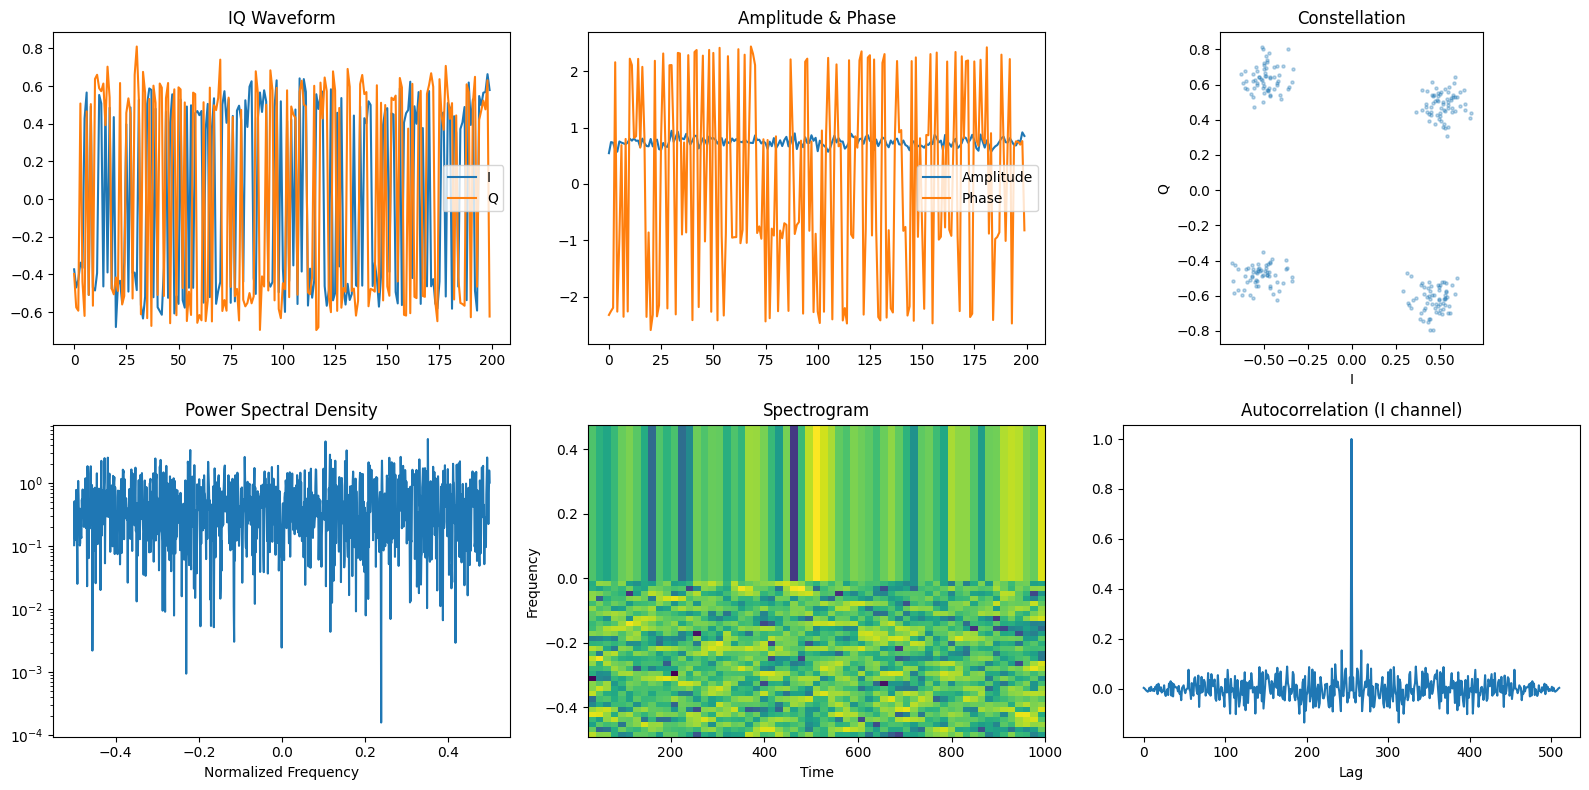

RFFI常用输入格式:
  1. 原始IQ: (2, N) - 最常用, 信息最完整
  2. 幅度/相位: (2, N) - 对相位旋转敏感
  3. 时频图: (1, F, T) - 可用2D CNN处理
  4. 频谱: (N,) - 丢失时域信息


In [4]:
# IQ信号的多种表示形式
I, Q = generate_device_iq(0, 1024)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. IQ波形
axes[0, 0].plot(I[:200], label='I')
axes[0, 0].plot(Q[:200], label='Q')
axes[0, 0].set_title('IQ Waveform')
axes[0, 0].legend()

# 2. 幅度与相位
amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)
axes[0, 1].plot(amplitude[:200], label='Amplitude')
axes[0, 1].plot(phase[:200], label='Phase')
axes[0, 1].set_title('Amplitude & Phase')
axes[0, 1].legend()

# 3. 星座图
axes[0, 2].scatter(I[::4], Q[::4], alpha=0.3, s=5)
axes[0, 2].set_title('Constellation')
axes[0, 2].set_xlabel('I')
axes[0, 2].set_ylabel('Q')
axes[0, 2].set_aspect('equal')

# 4. 功率谱密度
signal = I + 1j * Q
freqs = np.fft.fftshift(np.fft.fftfreq(len(signal)))
psd = np.fft.fftshift(np.abs(np.fft.fft(signal)))**2 / len(signal)
axes[1, 0].semilogy(freqs, psd)
axes[1, 0].set_title('Power Spectral Density')
axes[1, 0].set_xlabel('Normalized Frequency')

# 5. 时频图 (Spectrogram)
from scipy.signal import spectrogram as scipy_spectrogram
f, t_spec, Sxx = scipy_spectrogram(signal, nperseg=64, noverlap=48)
axes[1, 1].pcolormesh(t_spec, f, 10*np.log10(Sxx+1e-10), shading='auto', cmap='viridis')
axes[1, 1].set_title('Spectrogram')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Frequency')

# 6. 自相关函数
autocorr = np.correlate(I[:256], I[:256], mode='full')
autocorr = autocorr / autocorr.max()
axes[1, 2].plot(autocorr)
axes[1, 2].set_title('Autocorrelation (I channel)')
axes[1, 2].set_xlabel('Lag')

plt.tight_layout()
plt.show()

print("RFFI常用输入格式:")
print("  1. 原始IQ: (2, N) - 最常用, 信息最完整")
print("  2. 幅度/相位: (2, N) - 对相位旋转敏感")
print("  3. 时频图: (1, F, T) - 可用2D CNN处理")
print("  4. 频谱: (N,) - 丢失时域信息")

In [ ]:
# 生成完整的模拟数据集
n_devices = 10
samples_per_device = 200
iq_length = 128  # 每个样本的IQ长度

all_iq = []
all_labels = []

for dev_id in range(n_devices):
    for _ in range(samples_per_device):
        I, Q = generate_device_iq(dev_id, iq_length, snr=15)
        iq_sample = np.stack([I, Q], axis=0)  # (2, 128)
        all_iq.append(iq_sample)
        all_labels.append(dev_id)

X = np.array(all_iq, dtype=np.float32)
y = np.array(all_labels, dtype=np.int64)

# 归一化
X = X / (np.std(X) + 1e-8)

print(f"数据集: X={X.shape}, y={y.shape}")
print(f"设备数: {n_devices}, 每设备样本数: {samples_per_device}")
print(f"IQ长度: {iq_length}, 通道数: 2 (I+Q)")
print(f"数据范围: [{X.min():.2f}, {X.max():.2f}]")

# 划分数据集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

print(f"\n训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# 转为Tensor
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

---
## 2. 1D CNN 射频指纹分类器

1D CNN 是 RFFI 最经典也最有效的模型架构。

与图像用 2D 卷积不同, IQ信号是1D序列, 使用 1D 卷积:
- 输入: (batch, 2, N) — 2个通道(I和Q), N个采样点
- 1D卷积沿时间轴滑动, 提取时域特征
- 多层卷积逐步提取从细粒度到粗粒度的指纹特征

In [ ]:
# 经典 1D CNN 架构 (参考 RadioML 论文)
class RFFNet(nn.Module):
    def __init__(self, n_classes=10, input_length=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = RFFNet(n_classes=n_devices, input_length=iq_length)
print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
print()

# 查看模型结构
x = torch.randn(1, 2, 128)
print("各层输出形状:")
for name, layer in model.features.named_children():
    x = layer(x)
    print(f"  {name}: {x.shape}")

In [ ]:
# 训练函数
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total, loss_sum = 0, 0, 0
        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += X_batch.size(0)
            loss_sum += loss.item() * X_batch.size(0)
        
        train_accs.append(correct / total)
        train_losses.append(loss_sum / total)
        scheduler.step()
        
        model.eval()
        correct, total, loss_sum = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                correct += (logits.argmax(1) == y_batch).sum().item()
                total += X_batch.size(0)
                loss_sum += loss.item() * X_batch.size(0)
        
        val_accs.append(correct / total)
        val_losses.append(loss_sum / total)
    
    return train_losses, val_losses, train_accs, val_accs

torch.manual_seed(42)
model = RFFNet(n_classes=n_devices)
train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"最终验证准确率: {val_accs[-1]:.4f}")

---
## 3. RF数据增强技术

RF信号特有的数据增强方法, 模拟信道变化和接收机差异:

| 增强方法 | 模拟的物理现象 | 公式 |
|---------|--------------|------|
| 幅度缩放 | 路径损耗变化 | I' = a*I, Q' = a*Q |
| 相位旋转 | 载波相位偏移 | I'+jQ' = (I+jQ)*exp(jθ) |
| 频偏注入 | 多普勒/CFO | I'+jQ' = (I+jQ)*exp(j2πΔf*t) |
| 噪声注入 | 信噪比变化 | I' = I + n_I, Q' = Q + n_Q |
| 时间偏移 | 采样定时偏差 | 循环移位 |
| IQ交换 | 极性不确定 | I↔Q 或 I→-I

In [ ]:
class RFAugmentation:
    """RF信号数据增强"""
    
    @staticmethod
    def amplitude_scaling(iq, scale_range=(0.8, 1.2)):
        scale = np.random.uniform(*scale_range)
        return iq * scale
    
    @staticmethod
    def phase_rotation(iq, max_angle=np.pi/4):
        angle = np.random.uniform(-max_angle, max_angle)
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        I, Q = iq[0], iq[1]
        iq[0] = cos_a * I - sin_a * Q
        iq[1] = sin_a * I + cos_a * Q
        return iq
    
    @staticmethod
    def frequency_offset(iq, max_cfo=0.01):
        cfo = np.random.uniform(-max_cfo, max_cfo)
        t = np.linspace(0, 1, iq.shape[-1])
        phase = 2 * np.pi * cfo * t
        cos_p, sin_p = np.cos(phase), np.sin(phase)
        I, Q = iq[0], iq[1]
        iq[0] = cos_p * I - sin_p * Q
        iq[1] = sin_p * I + cos_p * Q
        return iq
    
    @staticmethod
    def noise_injection(iq, snr_range=(10, 30)):
        snr = np.random.uniform(*snr_range)
        signal_power = np.mean(iq ** 2)
        noise_power = signal_power / (10 ** (snr / 10))
        noise = np.sqrt(noise_power) * np.random.randn(*iq.shape)
        return iq + noise
    
    @staticmethod
    def time_shift(iq, max_shift=5):
        shift = np.random.randint(-max_shift, max_shift + 1)
        return np.roll(iq, shift, axis=-1)
    
    @staticmethod
    def random_apply(iq, aug_list, prob=0.5):
        for aug in aug_list:
            if np.random.random() < prob:
                iq = aug(iq)
        return iq

# 可视化增强效果
original_iq = X[0].copy()
aug = RFAugmentation()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
augs = [
    ('Original', original_iq),
    ('Amplitude Scaling', aug.amplitude_scaling(original_iq.copy())),
    ('Phase Rotation', aug.phase_rotation(original_iq.copy())),
    ('Frequency Offset', aug.frequency_offset(original_iq.copy())),
    ('Noise Injection', aug.noise_injection(original_iq.copy(), snr_range=(5, 5))),
    ('Time Shift', aug.time_shift(original_iq.copy())),
]

for ax, (name, iq_data) in zip(axes.flatten(), augs):
    ax.plot(iq_data[0][:80], label='I')
    ax.plot(iq_data[1][:80], label='Q')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 带数据增强的训练
class RFDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.augment = augment
        self.aug = RFAugmentation()
        self.aug_list = [
            self.aug.amplitude_scaling,
            self.aug.phase_rotation,
            self.aug.frequency_offset,
            self.aug.noise_injection,
            self.aug.time_shift,
        ]
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].numpy().copy()
        if self.augment:
            x = self.aug.random_apply(x, self.aug_list, prob=0.5)
        return torch.from_numpy(x), self.y[idx]

train_ds_aug = RFDataset(X_train, y_train, augment=True)
train_loader_aug = DataLoader(train_ds_aug, batch_size=64, shuffle=True)

torch.manual_seed(42)
model_aug = RFFNet(n_classes=n_devices)
train_losses_aug, val_losses_aug, train_accs_aug, val_accs_aug = train_model(
    model_aug, train_loader_aug, val_loader, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(val_losses, label='No Aug')
axes[0].plot(val_losses_aug, label='With Aug')
axes[0].set_title('Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(val_accs, label='No Aug')
axes[1].plot(val_accs_aug, label='With Aug')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"无增强 验证准确率: {val_accs[-1]:.4f}")
print(f"有增强 验证准确率: {val_accs_aug[-1]:.4f}")

---
## 4. 迁移学习与域适应

RFFI最大的挑战: **训练环境和部署环境不同** (信道、SNR、位置变化)。

```
源域 (实验室采集) → 目标域 (实际部署)
  SNR=30dB, 室内      SNR=10dB, 室外
  性能很好            性能大幅下降!
```

解决方案:
1. 迁移学习: 在源域预训练, 在目标域微调
2. 域适应: 对齐源域和目标域的特征分布
3. 域泛化: 训练时学习域不变特征

In [ ]:
# 模拟域偏移: 不同SNR下的性能
def generate_data_at_snr(n_devices, samples_per_device, iq_length, snr):
    all_iq, all_labels = [], []
    for dev_id in range(n_devices):
        for _ in range(samples_per_device):
            I, Q = generate_device_iq(dev_id, iq_length, snr=snr)
            iq_sample = np.stack([I, Q], axis=0)
            all_iq.append(iq_sample)
            all_labels.append(dev_id)
    X = np.array(all_iq, dtype=np.float32)
    y = np.array(all_labels, dtype=np.int64)
    X = X / (np.std(X) + 1e-8)
    return X, y

# 在高SNR训练, 测试不同SNR
model.eval()
snr_range = [0, 5, 10, 15, 20, 25, 30]
accs_by_snr = []

for snr in snr_range:
    X_snr, y_snr = generate_data_at_snr(n_devices, 100, iq_length, snr)
    with torch.no_grad():
        logits = model(torch.from_numpy(X_snr))
        acc = (logits.argmax(1) == torch.from_numpy(y_snr)).float().mean().item()
    accs_by_snr.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(snr_range, accs_by_snr, 'bo-', linewidth=2, markersize=8)
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Model Trained at SNR=15dB, Tested at Different SNRs')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()
print("SNR不匹配时性能显著下降, 这就是域偏移问题")

In [ ]:
# 迁移学习: 在目标域少量样本上微调
X_target, y_target = generate_data_at_snr(n_devices, 50, iq_length, snr=5)
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_target, y_target, test_size=0.4, random_state=42, stratify=y_target)

# 方案1: 直接用源域模型 (不微调)
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_t_test))
    acc_no_ft = (logits.argmax(1) == torch.from_numpy(y_t_test)).float().mean().item()

# 方案2: 全量微调
model_ft = RFFNet(n_classes=n_devices)
model_ft.load_state_dict(model.state_dict())  # 加载源域权重
ft_dataset = TensorDataset(torch.from_numpy(X_t_train), torch.from_numpy(y_t_train))
ft_loader = DataLoader(ft_dataset, batch_size=32, shuffle=True)

optimizer = optim.Adam(model_ft.parameters(), lr=1e-4)  # 小学习率
criterion = nn.CrossEntropyLoss()
for epoch in range(20):
    model_ft.train()
    for X_b, y_b in ft_loader:
        loss = criterion(model_ft(X_b), y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model_ft.eval()
with torch.no_grad():
    logits = model_ft(torch.from_numpy(X_t_test))
    acc_full_ft = (logits.argmax(1) == torch.from_numpy(y_t_test)).float().mean().item()

# 方案3: 只微调分类器 (冻结特征提取器)
model_partial = RFFNet(n_classes=n_devices)
model_partial.load_state_dict(model.state_dict())
for param in model_partial.features.parameters():
    param.requires_grad = False  # 冻结特征提取器

optimizer = optim.Adam(model_partial.classifier.parameters(), lr=1e-3)
for epoch in range(20):
    model_partial.train()
    for X_b, y_b in ft_loader:
        loss = criterion(model_partial(X_b), y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model_partial.eval()
with torch.no_grad():
    logits = model_partial(torch.from_numpy(X_t_test))
    acc_partial_ft = (logits.argmax(1) == torch.from_numpy(y_t_test)).float().mean().item()

print(f"源域模型 (不微调):     {acc_no_ft:.4f}")
print(f"全量微调:              {acc_full_ft:.4f}")
print(f"只微调分类器:          {acc_partial_ft:.4f}")
print()
print("迁移学习策略:")
print("  目标域数据多 → 全量微调 (小学习率)")
print("  目标域数据少 → 只微调分类器")
print("  目标域极少   → 冻结特征, 只训练最后一层")

In [ ]:
# 域适应: MMD (Maximum Mean Discrepancy)
def mmd_loss(source_features, target_features, kernel='rbf', gamma=1.0):
    """最大均值差异, 衡量两个分布的距离"""
    n_s = source_features.shape[0]
    n_t = target_features.shape[0]
    
    # 计算核矩阵
    xx = torch.cdist(source_features, source_features)**2
    yy = torch.cdist(target_features, target_features)**2
    xy = torch.cdist(source_features, target_features)**2
    
    K_xx = torch.exp(-gamma * xx)
    K_yy = torch.exp(-gamma * yy)
    K_xy = torch.exp(-gamma * xy)
    
    mmd = K_xx.sum() / (n_s * n_s) + K_yy.sum() / (n_t * n_t) - 2 * K_xy.sum() / (n_s * n_t)
    return mmd

# 带MMD的域适应训练
class DANN(nn.Module):
    """Domain Adaptation Neural Network"""
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = RFFNet(n_classes=n_classes).features
        self.classifier = nn.Linear(512, n_classes)
    
    def forward(self, x):
        feat = self.features(x)
        feat = feat.view(feat.size(0), -1)
        logits = self.classifier(feat)
        return logits, feat

print("域适应方法:")
print("  1. MMD: 最小化源域和目标域特征的MMD距离")
print("  2. DANN: 加入域判别器, 对抗训练使特征域不变")
print("  3. CORAL: 对齐源域和目标域的协方差")
print("  4. Mixup: 混合源域和目标域样本")
print()
print("总损失 = 分类损失 + λ * 域适应损失")
print("  λ 控制域适应的强度, 通常从小到大逐渐增加")

---
## 5. 分类评估与 Open-set 识别

RFFI 的评估比普通分类更复杂:
- 不仅要识别已知设备, 还要拒绝未知设备 (Open-set)
- 实际场景中可能出现训练时没见过的新设备

In [ ]:
# 标准分类评估
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b)
        all_preds.extend(logits.argmax(1).numpy())
        all_labels.extend(y_b.numpy())

# 混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 分类报告
print(classification_report(all_labels, all_preds, digits=3))
print(f"Macro F1: {f1_score(all_labels, all_preds, average='macro'):.4f}")

In [ ]:
# Open-set 识别: 拒绝未知设备
# 模拟5个未知设备
X_unknown, y_unknown = generate_data_at_snr(
    n_devices=5, samples_per_device=50, iq_length=iq_length, snr=15)
# 偏移设备ID, 使其与已知设备不同
y_unknown_offset = y_unknown + n_devices  # 标签 10-14 为未知设备

model.eval()
with torch.no_grad():
    logits_known = model(torch.from_numpy(X_test))
    probs_known = torch.softmax(logits_known, dim=1)
    max_prob_known = probs_known.max(dim=1).values.numpy()
    
    logits_unknown = model(torch.from_numpy(X_unknown))
    probs_unknown = torch.softmax(logits_unknown, dim=1)
    max_prob_unknown = probs_unknown.max(dim=1).values.numpy()

# 用最大概率作为置信度阈值
plt.figure(figsize=(8, 5))
plt.hist(max_prob_known, bins=30, alpha=0.6, label='Known Devices', color='blue')
plt.hist(max_prob_unknown, bins=30, alpha=0.6, label='Unknown Devices', color='red')
plt.xlabel('Max Softmax Probability')
plt.ylabel('Count')
plt.title('Open-set Recognition: Confidence Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 计算不同阈值下的拒绝率
print("Open-set 识别策略:")
print("  阈值越高 → 拒绝越多 → 已知设备准确率下降, 未知设备拒绝率提升")
print()
for threshold in [0.5, 0.7, 0.9, 0.95]:
    known_accept = (max_prob_known >= threshold).mean()
    unknown_reject = (max_prob_unknown < threshold).mean()
    print(f"  阈值={threshold:.2f}: 已知设备接受率={known_accept:.3f}, 未知设备拒绝率={unknown_reject:.3f}")

In [ ]:
# Open-set 方法总结
print("=== Open-set 识别方法 ===")
print()
print("1. 阈值法 (Baseline):")
print("   softmax最大概率 < 阈值 → 拒绝")
print("   简单但不可靠, 深度网络往往过度自信")
print()
print("2. ODIN (Out-of-Distribution Detector):")
print("   温度缩放 + 输入扰动, 增大已知/未知的概率差距")
print()
print("3. OpenMax:")
print("   在softmax之前校准激活值, 增加未知类")
print()
print("4. 度量学习 (Metric Learning):")
print("   学习嵌入空间, 用到类中心的距离判断")
print("   适合RFFI, 因为指纹本质是度量问题")
print()
print("5. 原型网络 (Prototypical Network):")
print("   每个类计算原型(中心), 用距离分类")
print("   天然支持Open-set和Few-shot")

---
## 6. 模型轻量化

RFFI 常需部署在边缘设备 (SDR、嵌入式接收机), 模型必须轻量。

In [ ]:
# 轻量化模型设计
class LightRFFNet(nn.Module):
    """轻量级RFFI模型"""
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# 深度可分离卷积版本
class DepthwiseRFFNet(nn.Module):
    """深度可分离卷积RFFI模型"""
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 2, 7, padding=3, groups=2),  # 深度卷积
            nn.Conv1d(2, 32, 1),                       # 逐点卷积
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 32, 5, padding=2, groups=32),
            nn.Conv1d(32, 64, 1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 64, 3, padding=1, groups=64),
            nn.Conv1d(64, 128, 1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

models = {
    'RFFNet (Original)': RFFNet(n_classes=10),
    'LightRFFNet': LightRFFNet(n_classes=10),
    'DepthwiseRFFNet': DepthwiseRFFNet(n_classes=10),
}

print("模型对比:")
print(f"{'模型':<25} {'参数量':>10} {'模型大小(KB)':>12}")
print("-" * 50)
for name, m in models.items():
    params = sum(p.numel() for p in m.parameters())
    size_kb = params * 4 / 1024  # float32
    print(f"{name:<25} {params:>10,} {size_kb:>12.1f}")

In [ ]:
# 知识蒸馏
print("=== 知识蒸馏 ===")
print()
print("用大模型(教师)指导小模型(学生)训练:")
print()
print("  教师模型: RFFNet (大, 准确率高)")
print("  学生模型: LightRFFNet (小, 部署友好)")
print()
print("蒸馏损失:")
print("  L = α * CE(y, y_student) + (1-α) * KL(softmax(z_teacher/T), softmax(z_student/T))")
print()
print("  T: 温度参数, T越大软标签越平滑")
print("  α: 平衡硬标签和软标签的权重")
print()
print("软标签包含类间关系信息 (如设备3和设备7的指纹相似),")
print("这些信息硬标签无法提供, 但对学生模型很有帮助")

In [ ]:
# 知识蒸馏实现
def distillation_train(teacher, student, train_loader, epochs=30, T=4.0, alpha=0.3):
    optimizer = optim.Adam(student.parameters(), lr=1e-3)
    ce_loss = nn.CrossEntropyLoss()
    kl_loss = nn.KLDivLoss(reduction='batchmean')
    
    teacher.eval()
    accs = []
    
    for epoch in range(epochs):
        student.train()
        correct, total = 0, 0
        for X_b, y_b in train_loader:
            with torch.no_grad():
                teacher_logits = teacher(X_b)
            
            student_logits = student(X_b)
            
            hard_loss = ce_loss(student_logits, y_b)
            soft_loss = kl_loss(
                F.log_softmax(student_logits / T, dim=1),
                F.softmax(teacher_logits / T, dim=1)
            ) * (T * T)
            
            loss = alpha * hard_loss + (1 - alpha) * soft_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            correct += (student_logits.argmax(1) == y_b).sum().item()
            total += X_b.size(0)
        accs.append(correct / total)
    return accs

torch.manual_seed(42)
student = LightRFFNet(n_classes=n_devices)
student_accs = distillation_train(model, student, train_loader, epochs=30)

print(f"知识蒸馏后学生模型准确率: {student_accs[-1]:.4f}")
print(f"教师模型参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"学生模型参数量: {sum(p.numel() for p in student.parameters()):,}")
print(f"压缩比: {sum(p.numel() for p in model.parameters()) / sum(p.numel() for p in student.parameters()):.1f}x")

---
## 7. 完整 RFFI 实验流程

In [ ]:
print("="" * 40)
print("RFFI 完整实验流程")
print("="" * 40)
print()
print("1. 数据采集")
print("   - 使用USRP/HackRF等SDR采集各设备的IQ信号")
print("   - 记录设备ID、SNR、信道条件等元数据")
print("   - 常用数据集: RadioML2016/2018, WiFi-RFF, Drone-RFF")
print()
print("2. 数据预处理")
print("   - IQ归一化: X = X / std(X)")
print("   - 截取固定长度 (如128/256/512采样点)")
print("   - 数据增强: 相位旋转、频偏、噪声注入")
print()
print("3. 模型选择")
print("   - 基线: 1D CNN (4-6层)")
print("   - 进阶: ResNet1D + SE注意力")
print("   - 轻量: 深度可分离1D CNN")
print("   - 少样本: 原型网络 / 孪生网络")
print()
print("4. 训练策略")
print("   - 优化器: AdamW, lr=1e-3, weight_decay=1e-4")
print("   - 学习率: CosineAnnealing")
print("   - 正则化: Dropout(0.5) + BatchNorm + 数据增强")
print("   - 标签平滑: label_smoothing=0.1")
print()
print("5. 评估指标")
print("   - 分类准确率 (Overall Accuracy)")
print("   - Macro F1-Score")
print("   - 混淆矩阵")
print("   - Open-set: AUROC, 拒绝率")
print("   - 跨SNR泛化曲线")
print()
print("6. 域适应 (如果需要)")
print("   - 迁移学习: 预训练 + 微调")
print("   - MMD / DANN: 无监督域适应")
print("   - 多SNR联合训练: 提高鲁棒性")
print()
print("7. 部署")
print("   - 知识蒸馏: 大模型 → 小模型")
print("   - 量化: FP32 → INT8")
print("   - ONNX导出: 跨平台部署")
print("   - 剪枝: 去除冗余参数")

In [ ]:
# RFFI 常用数据集
print("=== RFFI 常用数据集 ===")
print()
print("1. RadioML2016.10a")
print("   - 11种调制方式, SNR -20~30dB")
print("   - 220000个样本, IQ长度128")
print("   - 主要用于调制识别, 也可用于RFFI")
print()
print("2. RadioML2018.01a")
print("   - 24种调制方式, 更大规模")
print("   - 2555904个样本")
print()
print("3. WiSig / WiFi-RFF")
print("   - WiFi设备射频指纹")
print("   - 多个真实WiFi路由器")
print()
print("4. DroneRF")
print("   - 无人机射频指纹识别")
print()
print("5. 自建数据集")
print("   - 用USRP/HackRF采集")
print("   - 更贴近实际研究需求")
print()
print("数据集格式通常为 HDF5 或 pickle, IQ数据形状 (N, 2, 128)")

In [ ]:
# RFFI 前沿研究方向
print("=== RFFI 前沿研究方向 ===")
print()
print("1. 跨信道/跨场景泛化")
print("   - 实验室训练 → 室外部署, 性能骤降")
print("   - 域适应/域泛化是核心挑战")
print()
print("2. 少样本/零样本识别")
print("   - 新设备只有少量样本")
print("   - 度量学习、原型网络、元学习")
print()
print("3. Open-set 识别")
print("   - 拒绝未授权的未知设备")
print("   - 对抗性阈值、度量学习")
print()
print("4. 对抗鲁棒性")
print("   - 对抗攻击可以伪造指纹")
print("   - 对抗训练、认证检测")
print()
print("5. 多接收机协同")
print("   - 多个接收机联合识别")
print("   - 融合学习、联邦学习")
print()
print("6. 轻量化部署")
print("   - 边缘设备实时识别")
print("   - 知识蒸馏、量化、剪枝")
print()
print("7. 物理层安全")
print("   - RFFI用于IoT设备认证")
print("   - 与密码学结合")

---
## 总结

### RFFI 核心知识图谱

```
射频指纹识别 (RFFI)
├── 输入: IQ信号 (2, N)
│   ├── 原始IQ → 1D CNN (最常用)
│   ├── 时频图 → 2D CNN
│   └── 幅度/相位 → 多通道输入
│
├── 模型
│   ├── 1D CNN (基线)
│   ├── ResNet1D + SE (进阶)
│   ├── 深度可分离CNN (轻量)
│   └── 原型网络 (少样本)
│
├── 关键技术
│   ├── RF数据增强 (相位旋转/频偏/噪声)
│   ├── 迁移学习 (跨环境微调)
│   ├── 域适应 (MMD/DANN)
│   ├── Open-set识别
│   └── 知识蒸馏 (轻量部署)
│
└── 评估
    ├── 准确率 / F1
    ├── 混淆矩阵
    ├── 跨SNR泛化曲线
    └── Open-set AUROC
```

### 与已有课程的关联

| 已有课程 | 在RFFI中的应用 |
|---------|---------------|
| CNN (L7) | 1D CNN是RFFI核心模型 |
| 正则化 (L10) | Dropout+BN防止过拟合 |
| 优化器 (L9) | AdamW + CosineAnnealing |
| CNN架构 (L12) | ResNet1D, SE-Net用于RFFI |
| 注意力 (L14) | SE/通道注意力提升RFFI性能 |
| NumPy (L15) | IQ信号处理与可视化 |